In [1]:
import pandas as pd
import numpy as np
import psutil
from unidecode import unidecode
from fuzzywuzzy import fuzz
from rapidfuzz import fuzz as rfuzz
from metaphone import doublemetaphone as dm
from difflib import SequenceMatcher
from collections import defaultdict
import matplotlib.pyplot as plt
import json

# Check memory usage
def memory_usage():
    process = psutil.Process()
    mem_info = process.memory_info()
    return mem_info.rss / (1024 * 1024)  # Convert bytes to MB

print(f"Memory usage: {memory_usage()} MB")

/Users/ilkhom/miniconda3/envs/geojson/lib/python3.9/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


Memory usage: 130.7265625 MB


In [2]:
# Set pandas display options
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full column width
pd.set_option('display.expand_frame_repr', False)  # Disable wrapping of rows

In [3]:
# main = pd.read_csv('./compare_A.csv', encoding='utf-8', sep=',', low_memory=False)
# main.columns = ['himoya_id', 'himoya_name', 'regionserv_id', 'regionserv_name']

himoya_mahalla = pd.read_excel('./countryside_csv.xlsx', engine='openpyxl')
regions_mahalla = pd.read_excel('./countryside_geo.xlsx', engine='openpyxl')

himoya_tuman = pd.read_excel('./district_csv_sorted.xlsx', engine='openpyxl')
regions_tuman = pd.read_excel('./district_geo_sorted.xlsx', engine='openpyxl')

In [4]:
print(himoya_tuman.head(),'\n')
print(regions_tuman.head(),'\n')
print(himoya_mahalla.head(),'\n')
print(regions_mahalla.head(),'\n')

    id               created_at   latitude  longitude             name               updated_at  region_id  geometry_type  deleted
0  594  2023-08-03 15:52:24.461  60.076257  42.148884  Amudaryo tumani  2023-08-03 15:52:24.461         41            NaN    False
1  524  2023-08-03 15:52:15.398  72.356757  40.769366          Andijon  2023-08-03 15:52:15.398         35            NaN    False
2  510  2023-08-03 15:52:12.766  72.432173  40.804764   Andijon tumani  2023-08-03 15:52:12.766         35            NaN    False
3  542  2023-08-03 15:52:18.341  67.211952  37.440345     Angor tumani  2023-08-03 15:52:18.341         37            NaN    False
4  432  2023-08-03 15:51:59.427  70.110434  41.017367           Angren  2023-08-03 15:51:59.427         29            NaN    False 

   OBJECTID  parent_code     code                    region_name         district  region_cad_id  Shape_Length  Shape_Area
0       204         1735  1735204  Qoraqalpog‘iston respublikasi  Amudaryo tumani        

In [6]:
def floor(a, b):
	return np.floor(a * (10 ** b)) / (10 ** b)

In [7]:
item = himoya_mahalla[himoya_mahalla['name'].str.contains("rnek MFY")]
item
# math.floor(item.longitude*100)/100
print(floor(item.longitude, 3), '\n', floor(item.latitude, 3))

9315    42.449
Name: longitude, dtype: float64 
 9315    59.62
Name: latitude, dtype: float64


In [8]:
himoya_mahalla[(floor(himoya_mahalla['latitude'],3) == 59.620) & (floor(himoya_mahalla['longitude'],3) == 42.449)]

,id,created_at,latitude,longitude,name,updated_at,district_id,geometry_type,deleted,centroid,centroid_x,centroid_y
9315,22975,2023-10-03 18:23:58.526,59.620712,42.449009,O‘rnek MFY,2023-10-03 18:23:58.526,609,MultiPolygon,False,POINT (59.62084740436504 42.4490950583403),59.620847,42.449095


In [9]:
def fix_coords(row):
    lat, lon = row['latitude'], row['longitude']
    if lat <= 50 or lon >= 60:
        # swap lat and lon
        return pd.Series([lon, lat])
    else:
        return pd.Series([lat, lon])

himoya_mahalla[['latitude', 'longitude']] = himoya_mahalla.apply(fix_coords, axis=1)

In [9]:
himoya_mahalla['lat'] = himoya_mahalla['latitude'].apply(lambda x: floor(x, 3))
himoya_mahalla['lon'] = himoya_mahalla['longitude'].apply(lambda x: floor(x, 3))

regions_mahalla['lat'] = regions_mahalla['centroid_x'].apply(lambda x: floor(x, 3))
regions_mahalla['lon'] = regions_mahalla['centroid_y'].apply(lambda x: floor(x, 3))

# def near_coords(x1, x2, tol=0.005):
#     return abs(x1 - x2) < tol

# for i in range(len(himoya_mahalla)):
# 	for j in range(len(regions_mahalla)):
# 		if near_coords(himoya_mahalla['lat'][i], regions_mahalla['lat'][j]) and near_coords(himoya_mahalla['lon'][i], regions_mahalla['lon'][j]):
# 			himoya_mahalla.at[i, 'OBJECTID'] = regions_mahalla['OBJECTID'][j]

# merged = pd.merge(himoya_mahalla, regions_mahalla, how='outer', left_on=['regionserv_id'], right_on=['regionserv_id'])
# merged = merged[['himoya_id', 'himoya_name', 'regionserv_id', 'regionserv_name', 'latitude', 'longitude']]

In [10]:
import geopandas as gpd
from shapely.geometry import Point

# Convert to GeoDataFrames
# gdf1 = gpd.GeoDataFrame(himoya_mahalla, geometry=gpd.points_from_xy(himoya_mahalla.lon, himoya_mahalla.lat))
# gdf2 = gpd.GeoDataFrame(regions_mahalla, geometry=gpd.points_from_xy(regions_mahalla.lon, regions_mahalla.lat))
gdf1 = gpd.GeoDataFrame(himoya_mahalla, geometry=gpd.points_from_xy(himoya_mahalla.centroid_y, himoya_mahalla.centroid_x))
gdf2 = gpd.GeoDataFrame(regions_mahalla, geometry=gpd.points_from_xy(regions_mahalla.centroid_y, regions_mahalla.centroid_x))

# Set a CRS (coordinate reference system)
gdf1 = gdf1.set_crs("EPSG:4326")
gdf2 = gdf2.set_crs("EPSG:4326")

# Use spatial join with nearest
merged = gpd.sjoin_nearest(gdf1, gdf2[['mahalla_nomi','centroid','centroid_x','centroid_y','geometry','region_name','parent_code','district','code','mahalla_id','Geonames_id','Qayta_chegaralangan']], how="left", distance_col="dist_km")

/Users/ilkhom/miniconda3/envs/geojson/lib/python3.9/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [11]:
himoya_mahalla[himoya_mahalla['id'] == 14504]

,id,created_at,latitude,longitude,name,updated_at,district_id,geometry_type,deleted,centroid,centroid_x,centroid_y
9339,14504,2023-08-03 15:51:58.754,NaN,NaN,Fayzobod MFY,2023-08-03 15:51:58.754,427,NaN,False,POINT (69.21479054051936 41.39357544580216),69.214791,41.393575


In [12]:
fin_merged = pd.merge(merged, himoya_tuman, how='left', left_on=['district_id'], right_on=['id'])

In [13]:
len(himoya_mahalla) - len(fin_merged)

0

In [14]:
fin_merged['dist_in_km'] = fin_merged['dist_km'] * 111

In [ ]:
gdf_01 = fin_merged[fin_merged['dist_in_km'] < 0.1]

In [15]:
def is_phonetic(s1, s2):
    if not isinstance(s1, str) or not isinstance(s2, str):
        return False
    return dm(s1)[0] == dm(s2)[0]

def is_similar(a, b):
    if not isinstance(a, str) or not isinstance(b, str):
        return 0  # or return None, or whatever makes sense for you
    return SequenceMatcher(None, a, b).ratio()

In [16]:
fin_merged['mah_sim'] = fin_merged.apply(lambda x: rfuzz.ratio(x['name_x'],x['mahalla_nomi']), axis=1)
fin_merged['dist_sim'] = fin_merged.apply(lambda x: rfuzz.ratio(x['name_y'],x['district']), axis=1)

In [17]:
nan_merged = fin_merged[fin_merged[['mahalla_nomi','name_x']].isna().any(axis=1)]

In [18]:
nonan_merged = fin_merged.dropna(subset=['mahalla_nomi'])

In [ ]:
# unique_names = pd.concat([
#     df1[~df1['name'].isin(df2['name'])],
#     df2[~df2['name'].isin(df1['name'])]
# ])

In [19]:
similar_dists = nonan_merged[nonan_merged['dist_sim'] > 50]

In [20]:
len(similar_dists)

9415

In [21]:
similar_mahs = nonan_merged[nonan_merged['mah_sim'] >= 70]

In [22]:
len(similar_mahs)

8847

In [61]:
near_in_distance = nonan_merged[nonan_merged['dist_in_km'] < 100]

In [62]:
len(near_in_distance)

9523

In [65]:
all_ids = pd.concat([similar_dists['id_x'], similar_mahs['id_x'], near_in_distance['id_x']])
id_counts = all_ids.value_counts()
common_ids = id_counts[id_counts >= 2].index
no_common_ids = id_counts[id_counts == 1].index

In [64]:
print(len(himoya_mahalla),len(regions_mahalla))

9523 9452


In [44]:
filtered_data = pd.concat([
    similar_dists[similar_dists['id_x'].isin(common_ids)],
    similar_mahs[similar_mahs['id_x'].isin(common_ids)],
    near_in_distance[near_in_distance['id_x'].isin(common_ids)]
])
unduped_data = filtered_data.drop_duplicates().reset_index(drop=True)

In [66]:
unduped_data = pd.concat([similar_dists, similar_mahs, near_in_distance])

In [67]:
len(unduped_data)

27785

In [46]:
no_common_data = pd.concat([
    similar_dists[similar_dists['id_x'].isin(no_common_ids)],
    similar_mahs[similar_mahs['id_x'].isin(no_common_ids)],
    near_in_distance[near_in_distance['id_x'].isin(no_common_ids)]
])

In [50]:
no_common_merged = pd.concat([no_common_data, nan_merged], ignore_index=True)

In [ ]:
no_common_merged

In [ ]:
unduped_data.head()

In [52]:
len(fin_merged) - len(no_common_merged) - len(unduped_data)

7

In [53]:
len(fin_merged) - len(unduped_data)

200

In [54]:
fin_merged.head(1)

,id_x,created_at_x,latitude_x,longitude_x,name_x,updated_at_x,district_id,geometry_type_x,deleted_x,centroid_left,centroid_x_left,centroid_y_left,geometry,index_right,mahalla_nomi,centroid_right,centroid_x_right,centroid_y_right,region_name,parent_code,district,code,mahalla_id,Geonames_id,Qayta_chegaralangan,dist_km,id_y,created_at_y,latitude_y,longitude_y,name_y,updated_at_y,region_id,geometry_type_y,deleted_y,dist_in_km,mah_sim,dist_sim
0,23029,2023-11-28 17:40:55.382,70.320386,41.75896,uzgarish,2023-11-28 17:40:55.382,419,NaN,False,POINT (70.30998733438963 41.8507590935294),70.309987,41.850759,POINT (41.85076 70.30999),5508,Toshpo‘lat Dadaboyev MFY,POINT (70.34572682759294 41.83879314536062),70.345727,41.838793,Toshkent viloyati,1727,Boʻstonliq tumani,1727224,1727224054,АPU:788165,NaN,0.037689,419.0,2023-08-03 15:51:57.397,70.139955,41.692239,Bo'stonliq tumani,2023-09-07 12:05:52.743,29.0,NaN,False,4.18353,12.5,94.117647


In [ ]:
df_nan = fin_merged[fin_merged[['mahalla_nomi','name_x']].isna().any(axis=1)]

In [25]:
regions_geojson = gpd.read_file('./Mahalla_11_11_2024.geojson')

In [68]:
merged_geojson = pd.merge(unduped_data, regions_geojson, how='left', on=['mahalla_id'])
# merged_geojson = pd.merge(near_in_distance, regions_geojson, how='left', on=['mahalla_id'])

In [69]:
merged_geojson.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 27785 entries, 0 to 27784
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   id_x                   27785 non-null  int64   
 1   created_at_x           27785 non-null  object  
 2   latitude_x             27599 non-null  float64 
 3   longitude_x            27599 non-null  float64 
 4   name_x                 27785 non-null  object  
 5   updated_at_x           27785 non-null  object  
 6   district_id            27785 non-null  int64   
 7   geometry_type_x        11675 non-null  object  
 8   deleted_x              27785 non-null  bool    
 9   centroid_left          27785 non-null  object  
 10  centroid_x_left        27785 non-null  float64 
 11  centroid_y_left        27785 non-null  float64 
 12  geometry_x             27785 non-null  geometry
 13  index_right            27785 non-null  int64   
 14  mahalla_nomi_x         27785 n

In [70]:
merged_geojson.drop(columns=['geometry_type_x','deleted_x','centroid_left','centroid_x_left','geometry_x','index_right','Qayta_chegaralangan_x','id_y','created_at_y','latitude_y',
							 'centroid_y_right','longitude_y','updated_at_y','geometry_type_y','deleted_y','OBJECTID','region_name_y','parent_code_y','district_y',
							 'code_y','mahalla_nomi_y','Geonames_id_y','Qayta_chegaralangan_y','Shape_Length','Shape_Area','centroid_right'], inplace=True)

In [71]:
merged_geojson.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 27785 entries, 0 to 27784
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   id_x              27785 non-null  int64   
 1   created_at_x      27785 non-null  object  
 2   latitude_x        27599 non-null  float64 
 3   longitude_x       27599 non-null  float64 
 4   name_x            27785 non-null  object  
 5   updated_at_x      27785 non-null  object  
 6   district_id       27785 non-null  int64   
 7   centroid_y_left   27785 non-null  float64 
 8   mahalla_nomi_x    27785 non-null  object  
 9   centroid_x_right  27785 non-null  float64 
 10  region_name_x     27785 non-null  object  
 11  parent_code_x     27785 non-null  int64   
 12  district_x        27785 non-null  object  
 13  code_x            27785 non-null  int64   
 14  mahalla_id        27785 non-null  int64   
 15  Geonames_id_x     27785 non-null  object  
 16  dist_km       

In [ ]:
# merged_geojson.drop(columns=['geometry_y'], axis=1).head(20)

In [32]:
merged_geojson.to_file('./final_mahalla.geojson', driver='GeoJSON')	

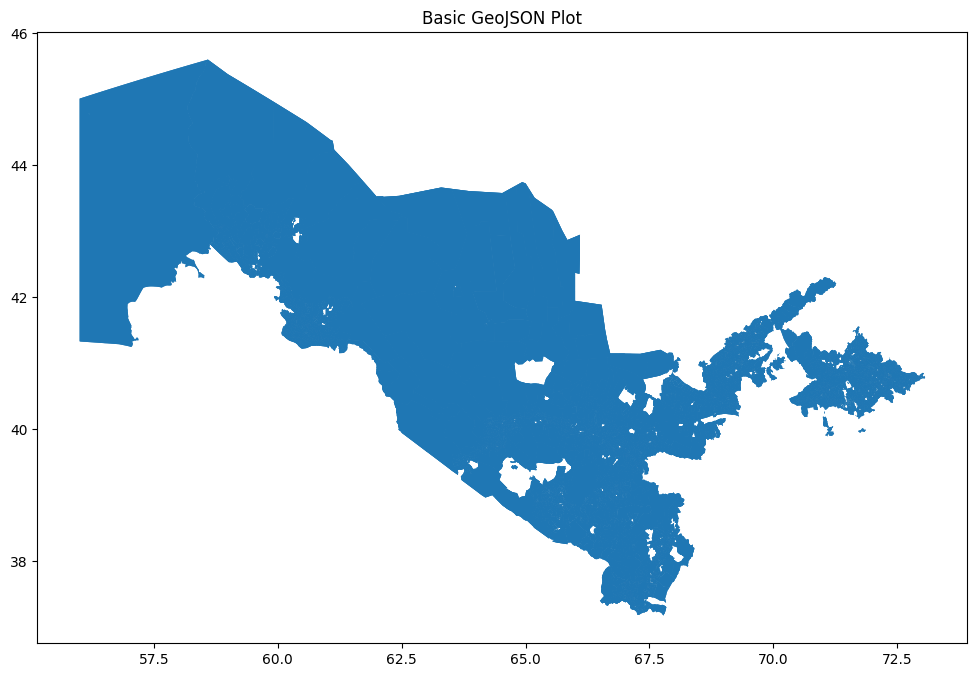

In [72]:
merged_geojson.set_geometry('geometry_y', inplace=True)
merged_geojson.plot(figsize=(12, 10))
plt.title("Basic GeoJSON Plot")
plt.show()

In [130]:
from keplergl import KeplerGl
import geopandas as gpd

gdf = gpd.read_file("Mahalla_11_11_2024.geojson")
gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.001, preserve_topology=True)
columns_to_display = ['mahalla_id', 'mahalla_nomi', 'district','region_name','geometry']
gdf_subset = gdf[columns_to_display]

map_1 = KeplerGl()
map_1.add_data(data=gdf_subset, name="GeoJSON Data")
map_1.save_to_html(file_name='./Mahalla_origin_geo.html')


User Guide: https://docs.kepler.gl/docs/keplergl-jupyter
Map saved to ./Mahalla_origin_geo.html!


In [35]:
from keplergl import KeplerGl
import geopandas as gpd

gdf = gpd.read_file("final_mahalla.geojson")
gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.001, preserve_topology=True)
columns_to_display = ['mahalla_id', 'mahalla_nomi_x', 'district_x','region_name_x','geometry']
gdf_subset = gdf[columns_to_display]

map_2 = KeplerGl()
map_2.add_data(data=gdf_subset, name="GeoJSON Data")
map_2.save_to_html(file_name='./final_mahalla.html')

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter
Map saved to ./final_mahalla.html!


In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
from shapely.geometry import MultiPolygon
from shapely.geometry import LineString
from shapely.geometry import MultiLineString
from keplergl import KeplerGl
import ast  # to safely parse the string into a list
import numpy as np

start_df = pd.read_csv('./countryside_dump.csv')

In [2]:
start_df['polygon_list'] = start_df['polygon'].apply(lambda x: ast.literal_eval(x))

In [3]:
start_df['level'] = start_df['polygon_list'].apply(lambda x: len(x))

In [4]:
def is_polygon(lst):
	try:
		if len(lst) == 1 and isinstance(lst[0], list):
			return Polygon(lst[0])
	except Exception as e:
		return None

start_df['geometry'] = start_df['polygon_list'].apply(is_polygon)

In [5]:
len(start_df)

9523

In [6]:
step_one_none_df = start_df[start_df['geometry'].isna()]
len(step_one_none_df)

846

In [7]:
def is_multipolygon(lst):
	try:
		return MultiPolygon(lst)
	except Exception as e:
		return None


step_one_none_df['geometry'] = step_one_none_df['polygon_list'].apply(is_multipolygon)

/var/folders/ww/67t1k6ss6bqfd8tw6ntmpfgm0000gn/T/ipykernel_57742/2525977106.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  step_one_none_df['geometry'] = step_one_none_df['polygon_list'].apply(is_multipolygon)


In [8]:
step_2_none_df = step_one_none_df[step_one_none_df['geometry'].isna()]
len(step_2_none_df)

206

In [9]:
def is_multilinestring(lst):
	try:
		return Polygon(lst)
	except Exception as e:
		return None


step_2_none_df['geometry'] = step_2_none_df['polygon_list'].apply(is_multilinestring)

/var/folders/ww/67t1k6ss6bqfd8tw6ntmpfgm0000gn/T/ipykernel_57742/4047732148.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  step_2_none_df['geometry'] = step_2_none_df['polygon_list'].apply(is_multilinestring)


In [10]:
step_3_none_df = step_2_none_df[step_2_none_df['geometry'].isna()]
len(step_3_none_df)

203

In [11]:
def is_deep_polygon(lst):
	try:
		return Polygon(lst[0])
	except Exception as e:
		return None


step_3_none_df['geometry'] = step_3_none_df['polygon_list'].apply(is_deep_polygon)
# step_3_none_df['polygon_list'].apply(is_deep_polygon)

/var/folders/ww/67t1k6ss6bqfd8tw6ntmpfgm0000gn/T/ipykernel_57742/2800048518.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  step_3_none_df['geometry'] = step_3_none_df['polygon_list'].apply(is_deep_polygon)


In [90]:
step_4_none_df = step_3_none_df[step_3_none_df['geometry'].isna()]
len(step_4_none_df)

38

In [91]:
step_4_none_df[['id','name','latitude','longitude','level']]

,id,name,latitude,longitude,level
28,74597,Atauba OFY,61.726217,41.577018,1
88,693371,Yangi diyor MFY,67.637468,40.181172,1
100,693431,Yoyilma MFY,67.961148,40.157464,1
107,693501,Oqtosh ota MFY,67.872964,40.047765,1
213,722771513,Annaroʻz MFY,66.188191,39.026102,1
673,21673,Batosh MFY,65.746466,38.832986,2
925,14911,Shexlyar MFY,66.551938,39.898467,2
981,14925,Chimkurgon MFY,66.563074,40.054173,3
1791,14592,Saxovat MFY,69.434017,41.144326,2
1830,14632,Karapchi MFY,68.822570,40.478872,2


2 Saxovat MFY 14592


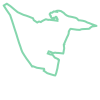

In [146]:
def show_polygon(i):
	try:
		el = step_4_none_df.iloc[i]
		print(len(el['polygon_list']), el['name'], el['id'])
		return MultiLineString(el['polygon_list'][0])
		# return Polygon(el['polygon_list'][0][0])
	except Exception as e:
		return None

show_polygon(8)

In [81]:
for i in range(len(step_4_none_df)):
	try:
		el = step_4_none_df.iloc[i]
		print(len(el['polygon_list']), el['name'], el['id'])
		MultiLineString(el['polygon_list'][0])
	except Exception as e:
		print('         Error',el['name'], el['id'])

# step_4_none_df['geometry'] = step_4_none_df['polygon_list'].apply(lambda x: Polygon(x[0][0]))
step_4_none_df['geometry'] = step_4_none_df['polygon_list'].apply(lambda x: MultiLineString(x[0]))

1 Atauba OFY 74597
1 Yangi diyor MFY 693371
1 Yoyilma MFY 693431
1 Oqtosh ota MFY 693501
1 Annaroʻz MFY 722771513
2 Batosh MFY 21673
2 Shexlyar MFY 14911
3 Chimkurgon MFY 14925
2 Saxovat MFY 14592
2 Karapchi MFY 14632
3 Ravot Olchin MFY 14968
3 Elbek MFY 15242
34 Qorasuv MFY 15341
2 G‘ijduvon MFY 15409
2 Sho‘r MFY 15607
2 Yangiobod MFY 15698
2 Yangiobod MFY 16078
2 Taraqqiyot MFY 16246
2 Muborak MFY 17669
2 Beshbulok MFY 17966
3 Pulxokim MFY 18113
2 Yangiarik MFY 18322
2 Sarjal OFY 18559
2 Xonchorbog MFY 18576
2 Yangi arik MFY 18584
2 Tinchlik MFY 20040
3 Chimqo'rg'on MFY 20199
2 Kattaming MFY 20391
2 Nurafshon MFY 20499
3 Chirokchi MFY 21317
2 Ipakchi MFY 21318
2 Xisorak MFY 21593
2 Okdaryo MFY 21606
3 Kuganli MFY 21757
2 Uyas MFY 21783
2 Yangi obod MFY 21805
2 Xujamulki MFY 21809
3 Buzachi MFY 22271


/var/folders/ww/67t1k6ss6bqfd8tw6ntmpfgm0000gn/T/ipykernel_57742/548654544.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  step_4_none_df['geometry'] = step_4_none_df['polygon_list'].apply(lambda x: MultiLineString(x[0]))


In [62]:
step_4_none_df['level'].value_counts()

level
2.0     24
3.0      8
1.0      5
34.0     1
Name: count, dtype: int64

In [33]:
df_arr = [start_df, step_one_none_df, step_2_none_df, step_3_none_df, step_4_none_df]
merged_dfs = pd.concat(df_arr, ignore_index=True)

geometries = merged_dfs[['id','geometry']]

def find_geom(row):
	id = row['id']
	geom = geometries[geometries['id'] == id]['geometry'].values[0]
	# print(f"ID: {id}, Geometry: {geom}")
	return geom

copy_df = start_df.copy()
copy_df['geometry'] = copy_df.apply(find_geom, axis=1)

In [82]:
flt_start_df = start_df[start_df['geometry'].notna()]
flt_step_one_none_df = step_one_none_df[step_one_none_df['geometry'].notna()]
flt_step_2_none_df = step_2_none_df[step_2_none_df['geometry'].notna()]
flt_step_3_none_df = step_3_none_df[step_3_none_df['geometry'].notna()]

flt_df = pd.concat([flt_start_df, flt_step_one_none_df, flt_step_2_none_df, flt_step_3_none_df, step_4_none_df], ignore_index=True)

In [83]:
flt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9523 entries, 0 to 9522
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             9523 non-null   int64  
 1   created_at     9523 non-null   object 
 2   latitude       9459 non-null   float64
 3   longitude      9459 non-null   float64
 4   name           9523 non-null   object 
 5   polygon        9523 non-null   object 
 6   updated_at     9523 non-null   object 
 7   district_id    9523 non-null   int64  
 8   geometry_type  4004 non-null   object 
 9   deleted        9523 non-null   bool   
 10  polygon_list   9523 non-null   object 
 11  level          9523 non-null   int64  
 12  geometry       9523 non-null   object 
dtypes: bool(1), float64(2), int64(3), object(7)
memory usage: 902.2+ KB


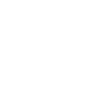

In [84]:
flt_df[flt_df['id'] == 17669]['geometry'].values[0]

In [85]:
# 3. Create Polygon objects
# def safe_polygon(coords):
#     if isinstance(coords, list):14504
#         return Polygon(coords[0])  # Single polygon
#     else:
#         return np.nan  # or you can skip, or put an empty geometry

# df['geometry'] = df['polygon_list'].apply(safe_polygon)
# df['geometry'] = df['polygon_list'].apply(lambda coords: Polygon(coords[0]))  # Assuming single Polygon
# df.drop(columns=['polygon_list','polygon'], inplace=True)

# 4. Create a GeoDataFrame
gdf = gpd.GeoDataFrame(flt_df, geometry='geometry')
gdf['geometry'] = gdf['geometry'].simplify(tolerance=0.001, preserve_topology=True)
columns_to_display = ['id', 'name', 'district_id','geometry']
gdf_subset = gdf[columns_to_display]

# 5. Load into KeplerGl
map_1 = KeplerGl()
map_1.add_data(data=gdf_subset, name='Polygons Map')

# 6. Save or display
map_1.save_to_html(file_name='polygons_map.html')

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter
Map saved to polygons_map.html!


In [149]:
gdf.drop(columns=['polygon_list','polygon','level'], inplace=True)
gdf.to_file('./countryside_dump.geojson', driver='GeoJSON')

/Users/ilkhom/miniconda3/envs/geojson/lib/python3.9/site-packages/pyogrio/geopandas.py:662: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [150]:
gdf['centroid'] = gdf.geometry.centroid
gdf['centroid_x'] = gdf.centroid.x
gdf['centroid_y'] = gdf.centroid.y
gdf.drop(columns=['geometry'], inplace=True)
gdf.head(1)

,id,created_at,latitude,longitude,name,updated_at,district_id,geometry_type,deleted,centroid,centroid_x,centroid_y
0,23029,2023-11-28 17:40:55.382,70.320386,41.75896,uzgarish,2023-11-28 17:40:55.382,419,NaN,False,POINT (70.30999 41.85076),70.309987,41.850759


In [153]:
gdf.to_excel('countryside_csv.xlsx', index=False)